In [51]:
#DATA COLLECTION
import yfinance as yf
import pandas as pd

In [52]:
tickers=['TCS.NS','INFY.NS','WIPRO.NS', #IT INDUSTRY
         'HDFCBANK.NS','ICICIBANK.NS','SBIN.NS',  #BANKS
         'ITC.NS','HINDUNILVR.NS','NESTLEIND.NS'  #FMCG
         ]

In [53]:
data=yf.download(tickers,period='5y')

[*********************100%***********************]  9 of 9 completed


In [54]:
print(data.head())

Price            Close                                                      \
Ticker     HDFCBANK.NS HINDUNILVR.NS ICICIBANK.NS      INFY.NS      ITC.NS   
Date                                                                         
2021-03-22  695.771606   2164.015137   554.633789  1206.743164  177.661346   
2021-03-23  710.452820   2149.394043   567.158813  1207.403442  174.674118   
2021-03-24  700.341736   2132.197266   548.878967  1191.733398  169.760895   
2021-03-25  693.024719   2057.202881   552.796021  1174.171143  166.341324   
2021-03-26  706.261475   2131.552979   559.566345  1176.283936  165.791031   

Price                                                               High  ...  \
Ticker     NESTLEIND.NS     SBIN.NS       TCS.NS    WIPRO.NS HDFCBANK.NS  ...   
Date                                                                      ...   
2021-03-22   784.164001  338.636993  2751.202637  191.455032  707.966494  ...   
2021-03-23   788.574463  343.896515  2762.587402  1

In [55]:
#DATA CLEANING
data=data['Close']

In [56]:
data=data.dropna()

In [57]:
print("Shape:",data.shape)
print("Missing values:",data.isnull().sum().sum())
print(data.head())

Shape: (1237, 9)
Missing values: 0
Ticker      HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS      INFY.NS      ITC.NS  \
Date                                                                            
2021-03-22   695.771606    2164.015137    554.633789  1206.743164  177.661346   
2021-03-23   710.452820    2149.394043    567.158813  1207.403442  174.674118   
2021-03-24   700.341736    2132.197266    548.878967  1191.733398  169.760895   
2021-03-25   693.024719    2057.202881    552.796021  1174.171143  166.341324   
2021-03-26   706.261475    2131.552979    559.566345  1176.283936  165.791031   

Ticker      NESTLEIND.NS     SBIN.NS       TCS.NS    WIPRO.NS  
Date                                                           
2021-03-22    784.164001  338.636993  2751.202637  191.455032  
2021-03-23    788.574463  343.896515  2762.587402  191.940063  
2021-03-24    777.548279  332.039581  2743.686768  189.861298  
2021-03-25    764.406250  327.748932  2694.239014  184.618179  
2021-03-26   

In [58]:
data.to_csv("data/nifty_data.csv")

In [59]:
sector_map={'TCS.NS':'IT','INFY.NS':'IT','WIPRO':'IT','HDFCBANK.IN':'Banking','ICICIBANK.NS':'Banking','SBIN.NS':'Banking','ITC.NS':'FMCG','HINDUNILVR.NS':'FMCG','NESTLEIND.NS':'FMCG'}

In [60]:
#PREPARATION
returns=data.pct_change().dropna()
print(returns.head())

Ticker      HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS    ITC.NS  \
Date                                                                       
2021-03-23     0.021101      -0.006756      0.022583  0.000547 -0.016814   
2021-03-24    -0.014232      -0.008001     -0.032231 -0.012978 -0.028128   
2021-03-25    -0.010448      -0.035172      0.007136 -0.014737 -0.020143   
2021-03-26     0.019100       0.036141      0.012247  0.001799 -0.003308   
2021-03-30     0.041843       0.034881      0.022297  0.036746  0.017307   

Ticker      NESTLEIND.NS   SBIN.NS    TCS.NS  WIPRO.NS  
Date                                                    
2021-03-23      0.005624  0.015531  0.004138  0.002533  
2021-03-24     -0.013982 -0.034478 -0.006842 -0.010830  
2021-03-25     -0.016902 -0.012922 -0.018022 -0.027616  
2021-03-26      0.024839  0.005631  0.000636  0.010634  
2021-03-30      0.035799  0.010078  0.029917  0.035157  


In [61]:
mean_returns=returns.mean()
print(mean_returns.head())

Ticker
HDFCBANK.NS      0.000178
HINDUNILVR.NS    0.000049
ICICIBANK.NS     0.000741
INFY.NS          0.000150
ITC.NS           0.000504
dtype: float64


In [62]:
volatility=returns.std()
print(volatility.head())

Ticker
HDFCBANK.NS      0.013045
HINDUNILVR.NS    0.012668
ICICIBANK.NS     0.013144
INFY.NS          0.015334
ITC.NS           0.012639
dtype: float64


In [ ]:
rolling_vol=returns.rolling(21).std()
print(rolling_vol.head())  #The first 21 days will have NAN values because a 21 day window is required to calculate rolling volatility.

Ticker      HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS  INFY.NS  ITC.NS  \
Date                                                                    
2021-03-23          NaN            NaN           NaN      NaN     NaN   
2021-03-24          NaN            NaN           NaN      NaN     NaN   
2021-03-25          NaN            NaN           NaN      NaN     NaN   
2021-03-26          NaN            NaN           NaN      NaN     NaN   
2021-03-30          NaN            NaN           NaN      NaN     NaN   

Ticker      NESTLEIND.NS  SBIN.NS  TCS.NS  WIPRO.NS  
Date                                                 
2021-03-23           NaN      NaN     NaN       NaN  
2021-03-24           NaN      NaN     NaN       NaN  
2021-03-25           NaN      NaN     NaN       NaN  
2021-03-26           NaN      NaN     NaN       NaN  
2021-03-30           NaN      NaN     NaN       NaN  


In [64]:
correlation=returns.corr()
print(correlation)

Ticker         HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS    ITC.NS  \
Ticker                                                                        
HDFCBANK.NS       1.000000       0.197110      0.510693  0.257800  0.213598   
HINDUNILVR.NS     0.197110       1.000000      0.169684  0.198396  0.316554   
ICICIBANK.NS      0.510693       0.169684      1.000000  0.244910  0.269406   
INFY.NS           0.257800       0.198396      0.244910  1.000000  0.167960   
ITC.NS            0.213598       0.316554      0.269406  0.167960  1.000000   
NESTLEIND.NS      0.170021       0.502160      0.166301  0.168629  0.282922   
SBIN.NS           0.406794       0.111535      0.538565  0.190693  0.287794   
TCS.NS            0.236177       0.230759      0.217651  0.710029  0.151923   
WIPRO.NS          0.281375       0.139950      0.254590  0.633316  0.179831   

Ticker         NESTLEIND.NS   SBIN.NS    TCS.NS  WIPRO.NS  
Ticker                                                     
HDFCBANK.N

In [65]:
sector_returns=returns.T.groupby(sector_map).mean().T #It gives the returns based on sector
print(sector_returns.head())

Ticker       Banking      FMCG        IT
Date                                    
2021-03-23  0.019057 -0.005982  0.002343
2021-03-24 -0.033354 -0.016704 -0.009910
2021-03-25 -0.002893 -0.024073 -0.016380
2021-03-26  0.008939  0.019224  0.001218
2021-03-30  0.016188  0.029329  0.033332


In [66]:
#VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

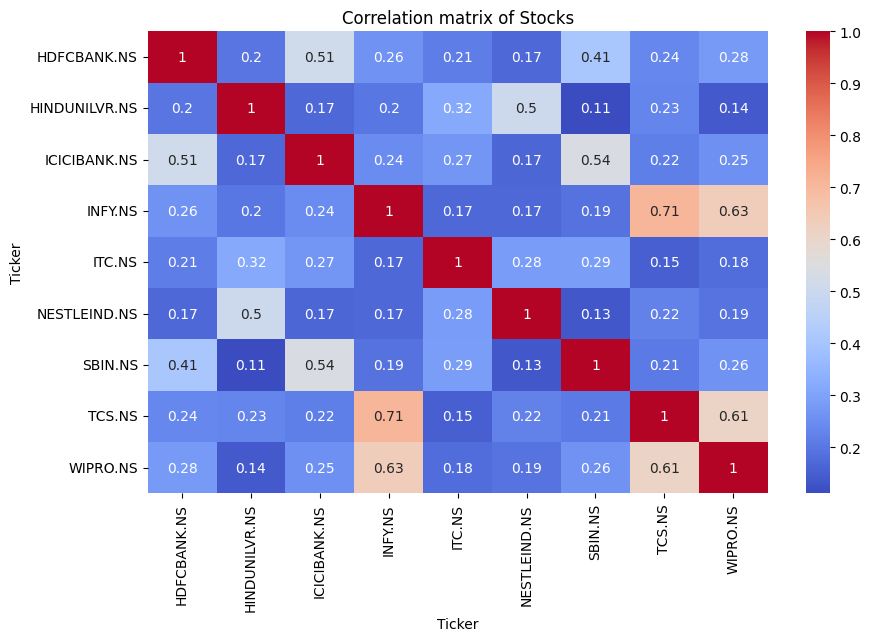

In [67]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title("Correlation matrix of Stocks")
plt.show()


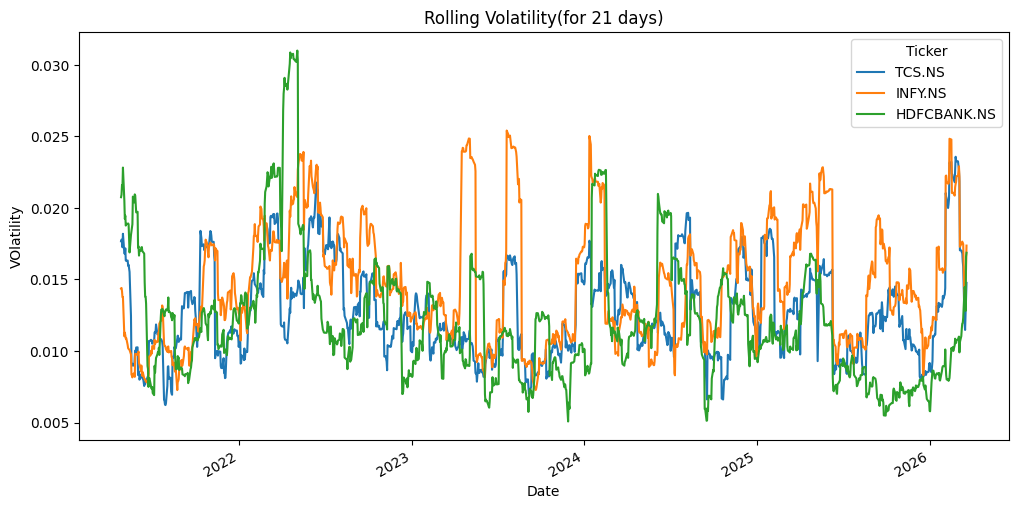

In [ ]:
rolling_vol[['TCS.NS','INFY.NS','HDFCBANK.NS']].plot(figsize=(12,6))  #For selected stocks
plt.title("Rolling Volatility(for 21 days)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()  #This plot shows volatility clustering.

In [69]:
sector_vol=returns.T.groupby(sector_map).std().T
sector_vol_mean=sector_vol.mean()

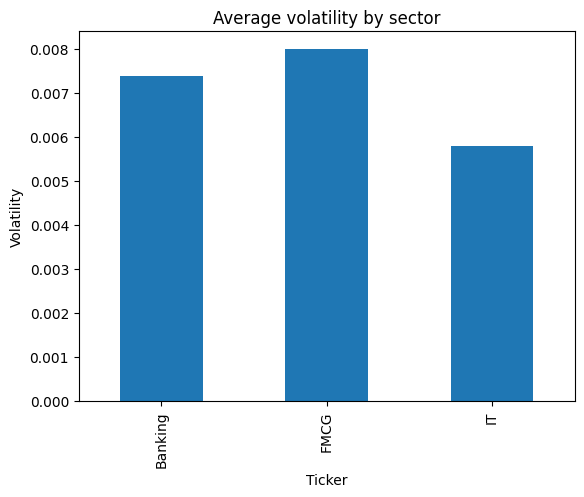

In [ ]:
sector_vol_mean.plot(kind='bar')
plt.title("Average volatility by sector")
plt.ylabel("Volatility")
plt.show() #This analysis indicates that FMCG sector has the highest volatility among all three sectors,suggesting higher risk during the period.

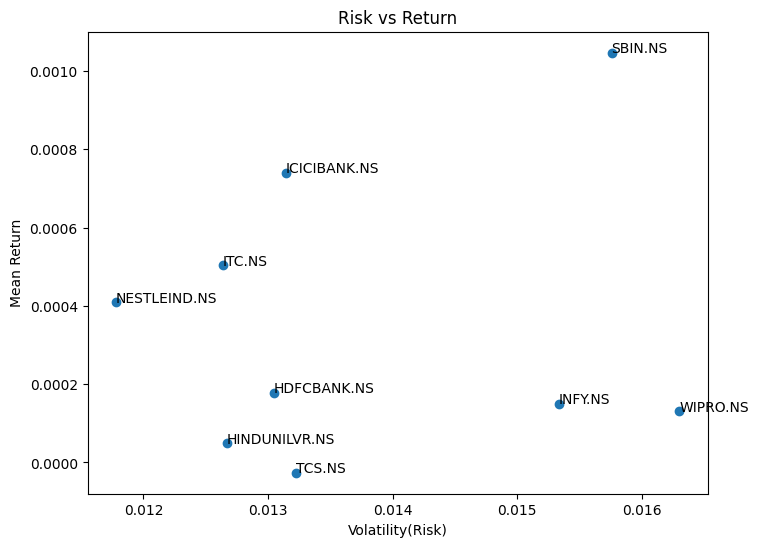

In [71]:
plt.figure(figsize=(8,6))
plt.scatter(volatility,mean_returns)
for stock in mean_returns.index:
    plt.text(volatility[stock],mean_returns[stock],stock)
plt.xlabel("Volatility(Risk)")
plt.ylabel("Mean Return")
plt.title("Risk vs Return")
plt.show() #Stocks located in the upper left offer better risk-adjusted returns meanwhile those in lower right indicate inefficient risk-return trade-offs

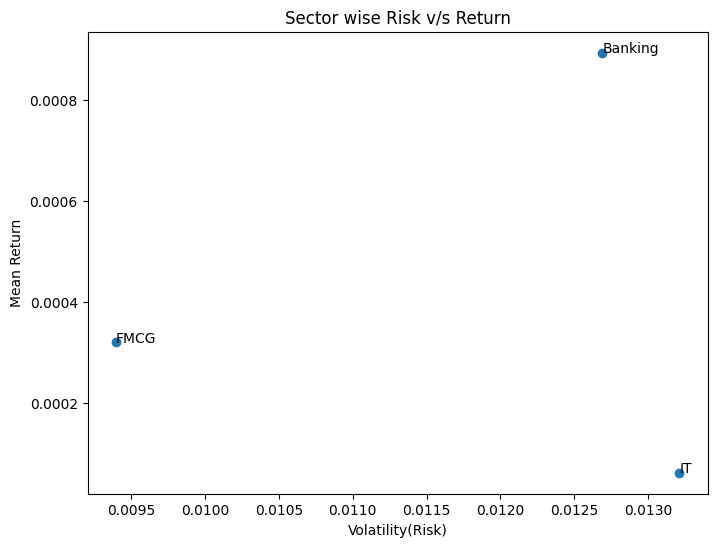

In [77]:
sector_return_mean=sector_returns.mean()
sector_vol1=sector_returns.std()
plt.figure(figsize=(8,6))
plt.scatter(sector_vol1,sector_return_mean)
for sector in sector_return_mean.index:
    plt.text(sector_vol1[sector],sector_return_mean[sector],sector)
plt.xlabel("Volatility(Risk)")
plt.ylabel("Mean Return")
plt.title("Sector wise Risk v/s Return")
plt.show()

In [ ]:
#Data Storage and SQL Analysis
import sqlite3
conn=sqlite3.connect("nifty_analysis.db")
returns.to_sql("returns",conn,if_exists="replace")

1236

In [73]:
query="SELECT * from returns LIMIT 5"
result=pd.read_sql(query,conn)
result

,Date,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,NESTLEIND.NS,SBIN.NS,TCS.NS,WIPRO.NS
0,2021-03-23 00:00:00,0.021101,-0.006756,0.022583,0.000547,-0.016814,0.005624,0.015531,0.004138,0.002533
1,2021-03-24 00:00:00,-0.014232,-0.008001,-0.032231,-0.012978,-0.028128,-0.013982,-0.034478,-0.006842,-0.010830
2,2021-03-25 00:00:00,-0.010448,-0.035172,0.007136,-0.014737,-0.020143,-0.016902,-0.012922,-0.018022,-0.027616
3,2021-03-26 00:00:00,0.019100,0.036141,0.012247,0.001799,-0.003308,0.024839,0.005631,0.000636,0.010634
4,2021-03-30 00:00:00,0.041843,0.034881,0.022297,0.036746,0.017307,0.035799,0.010078,0.029917,0.035157


In [ ]:
vol_df=volatility.reset_index()
vol_df.columns=['Stock','Volatility']
vol_df.to_sql("volatility",conn,if_exists="replace",index=False)
query="""SELECT * from volatility order by Volatility DESC LIMIT 1"""
print(pd.read_sql(query,conn))# This analysis shows that WIPRO.NS stock has the highest volatility of all the stocks

      Stock  Volatility
0  WIPRO.NS    0.016301


In [ ]:
mean_df=mean_returns.reset_index()
mean_df.columns=['Stock','MeanReturn']
mean_df.to_sql("mean_returns",conn,if_exists="replace",index=False)
query="""SELECT * from  mean_returns order by MeanReturn DESC"""
print(pd.read_sql(query,conn)) #This analysis retrieves and displays the mean returns of each stock in descending order

           Stock  MeanReturn
0        SBIN.NS    0.001047
1   ICICIBANK.NS    0.000741
2         ITC.NS    0.000504
3   NESTLEIND.NS    0.000409
4    HDFCBANK.NS    0.000178
5        INFY.NS    0.000150
6       WIPRO.NS    0.000131
7  HINDUNILVR.NS    0.000049
8         TCS.NS   -0.000026


In [ ]:
#  Insights 
#       Different methods of volatility estimation yield varying insights, emphasizing the need of careful interpretation
#       Banking sector is by-far the best sector in providing best returns albeit a higher risk is involved
#       IT sector is the most inefficient sector out of the bunch as it not only has high risk but it's returns are also very bad     
   